In [41]:
import json
import wandb
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

from matplotlib import pyplot as plt

In [27]:
agent = wandb.Api()

In [28]:
table = agent.run("p16i/xaikd-s41-why-heatmaps-are-bad/runs/5fy24llm")\
    .logged_artifacts()[0]

In [29]:
table.download()

wandb:   1 of 1 files downloaded.  


'./artifacts/run-5fy24llm-prediction:v0'

In [42]:
def load_prediction_from_artifact(run_path: str):
    run = agent.run(run_path)
    table = run \
        .logged_artifacts()[0]
    table_dir = table.download()
    
    table_name = "prediction"
    table_path = f"{table_dir}/{table_name}.table.json"
    with open(table_path) as file:
        json_dict = json.load(file)
    return pd.DataFrame(json_dict["data"], columns=json_dict["columns"])
    
df_pca = load_prediction_from_artifact("p16i/xaikd-s41-why-heatmaps-are-bad/runs/5fy24llm")

wandb:   1 of 1 files downloaded.  


In [39]:
df_pca

,target,student_pred,teacher_pred
0,0,0,0
1,0,0,1
2,0,0,0
3,0,0,0
4,0,1,0
...,...,...,...
295,5,5,5
296,5,5,5
297,5,5,5
298,5,5,5


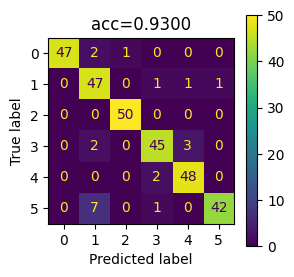

In [49]:
def confusion_matrix(y_target, y_pred):
    
    plt.figure(figsize=(3, 3))

    ConfusionMatrixDisplay.from_predictions(y_target, y_pred, ax=plt.gca())
    plt.title(f"acc={(y_target == y_pred).mean():.4f}")

confusion_matrix(df_pca.target, df_pca.teacher_pred)

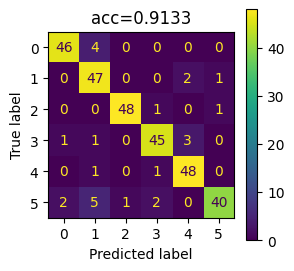

In [50]:
confusion_matrix(df_pca.target, df_pca.student_pred)

In [32]:
df_prca = load_prediction_from_artifact("p16i/xaikd-s41-why-heatmaps-are-bad/runs/baqnflxy")

wandb:   1 of 1 files downloaded.  


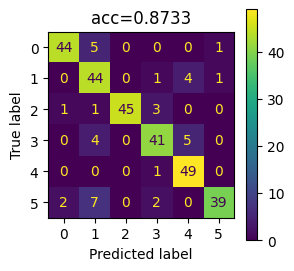

In [52]:
confusion_matrix(df_prca.target, df_prca.student_pred)